# Practical 5
Take 5 real data sets. For each data set: (5 hours) <br>
a. Use a library and run a (heuristic)algorithm for the k-centre problem. Record
the cost and the time. Run on toy data first.<br>
b. Implement/Use and run a greedy 2-approximation algorithm for the k-centre
algorithm. Record the cost and the time, and compare with the observations in
part (a). Run on toy data first.

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

In [4]:
def k_centre_cost(points, centers):
    cost = 0
    for p in points:
        dist = min([euclidean_distance(p, c) for c in centers])
        cost = max(cost, dist)
    return cost

In [5]:
def kcentre_library(points, k):
    start = time.time()

    km = KMeans(n_clusters=k, n_init=10)
    km.fit(points)

    centers = km.cluster_centers_
    cost = k_centre_cost(points, centers)

    end = time.time()
    return centers, cost, (end - start)*1000

In [6]:
def kcentre_greedy(points, k):
    start = time.time()
    points = np.array(points)

    # choose first center
    centers = [points[np.random.randint(0, len(points))]]

    # repeatedly add farthest point
    for _ in range(1, k):
        distances = np.array([min([euclidean_distance(p, c) for c in centers])
                              for p in points])
        new_center = points[np.argmax(distances)]
        centers.append(new_center)

    cost = k_centre_cost(points, centers)
    end = time.time()
    return centers, cost, (end - start)*1000


In [7]:
toy_points = np.random.rand(100, 2)
k = 3

lib_centers, lib_cost, lib_time = kcentre_library(toy_points, k)
gr_centers, gr_cost, gr_time = kcentre_greedy(toy_points, k)

print("Toy Data:")
print("Library Cost:", lib_cost, "Time(ms):", lib_time)
print("Greedy Cost:", gr_cost, "Time(ms):", gr_time)

Toy Data:
Library Cost: 0.5067144757158938 Time(ms): 264.7526264190674
Greedy Cost: 0.8161764054628663 Time(ms): 4.507303237915039


In [8]:
datasets = {
    "iris": load_iris().data,
    "wine": load_wine().data,
    "digits": StandardScaler().fit_transform(load_digits().data[:300]),
    "random2D_A": np.random.rand(200,2),
    "random2D_B": np.random.rand(300,2)
}

In [9]:
results = []

k = 5

for name, data in datasets.items():
    print(f"Running on dataset: {name}")

    #A:Library Heuristic
    lib_centers, lib_cost, lib_time = kcentre_library(data, k)

    #B:Greedy 2-approx
    gr_centers, gr_cost, gr_time = kcentre_greedy(data, k)

    results.append([
        name, k,
        lib_cost, lib_time,
        gr_cost, gr_time
    ])

df = pd.DataFrame(results, columns=[
    "Dataset", "k",
    "Library Cost", "Library Time(ms)",
    "Greedy Cost", "Greedy Time(ms)"
])

display(df)

Running on dataset: iris
Running on dataset: wine
Running on dataset: digits
Running on dataset: random2D_A
Running on dataset: random2D_B


,Dataset,k,Library Cost,Library Time(ms),Greedy Cost,Greedy Time(ms)
0,iris,5,1.248030,42.173386,1.627882,9.143591
1,wine,5,319.164092,40.035963,208.898856,14.022112
2,digits,5,20.918810,61.862469,18.991533,29.439688
3,random2D_A,5,0.364079,45.589924,0.479821,18.507004
4,random2D_B,5,0.347768,53.066969,0.534056,30.031681


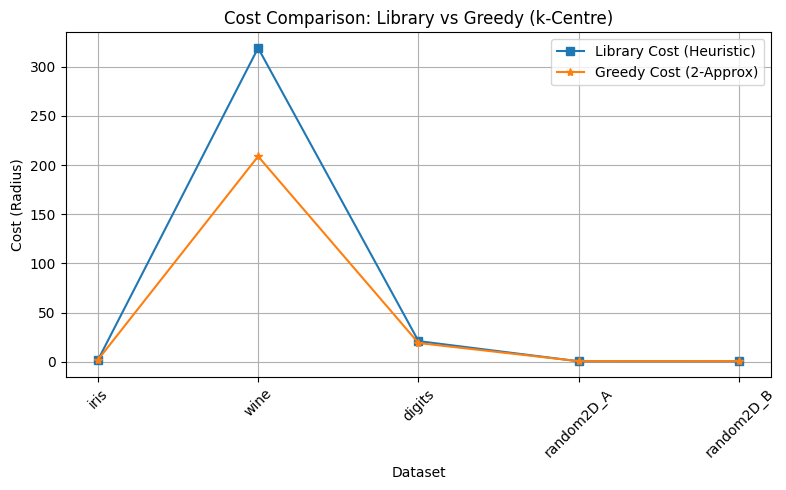

In [10]:
plt.figure(figsize=(8,5))
plt.plot(df["Dataset"], df["Library Cost"], marker="s", label="Library Cost (Heuristic)")
plt.plot(df["Dataset"], df["Greedy Cost"], marker="*", label="Greedy Cost (2-Approx)")
plt.xlabel("Dataset")
plt.ylabel("Cost (Radius)")
plt.title("Cost Comparison: Library vs Greedy (k-Centre)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("kcentre_cost_comparison.png")
plt.show()

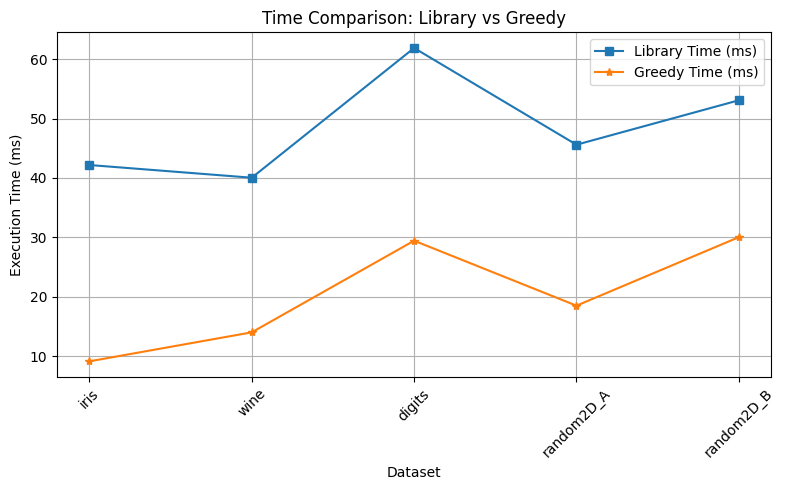

In [11]:
plt.figure(figsize=(8,5))
plt.plot(df["Dataset"], df["Library Time(ms)"], marker="s", label="Library Time (ms)")
plt.plot(df["Dataset"], df["Greedy Time(ms)"], marker="*", label="Greedy Time (ms)")
plt.xlabel("Dataset")
plt.ylabel("Execution Time (ms)")
plt.title("Time Comparison: Library vs Greedy")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("kcentre_time_comparison.png")
plt.show()

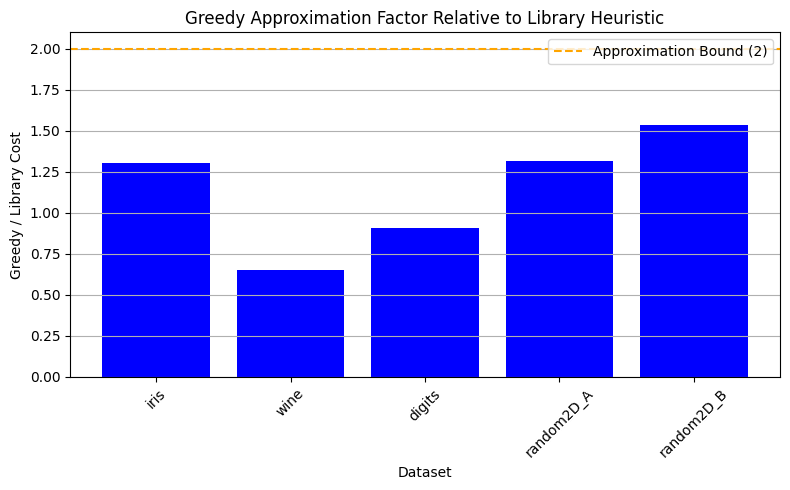

In [12]:
df["Ratio"] = df["Greedy Cost"] / df["Library Cost"]

plt.figure(figsize=(8,5))
plt.bar(df["Dataset"], df["Ratio"], color="b")
plt.axhline(2, color='orange', linestyle='--', label="Approximation Bound (2)")
plt.ylabel("Greedy / Library Cost")
plt.xlabel("Dataset")
plt.title("Greedy Approximation Factor Relative to Library Heuristic")
plt.legend()
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("kcentre_ratio_comparison.png")
plt.show()

In [13]:
# from google.colab import files
df.to_csv("practical5_results.csv", index=False)
# files.download("practical5_results.csv")